# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [ ]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [ ]:
from google.colab import files

uploaded = files.upload()
csv_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))
df.head()

Saving Country-data (1).csv to Country-data (1).csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [ ]:
print('Shape:', df.shape)
display(df.info())
display(df.isnull().sum())
display(df.describe(include='all').T)

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [ ]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [ ]:
df.columns = df.columns.str.strip()
df = df.drop_duplicates()
country = df["country"]
features = df.drop("country", axis=1)
features = features.apply(pd.to_numeric, errors="coerce")
features = features.fillna(features.median())
numeric_cols = features.columns
df = features.copy()
df["country"] = country
df = df[["country"] + list(numeric_cols)]
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 7) Exploratory Data Analysis

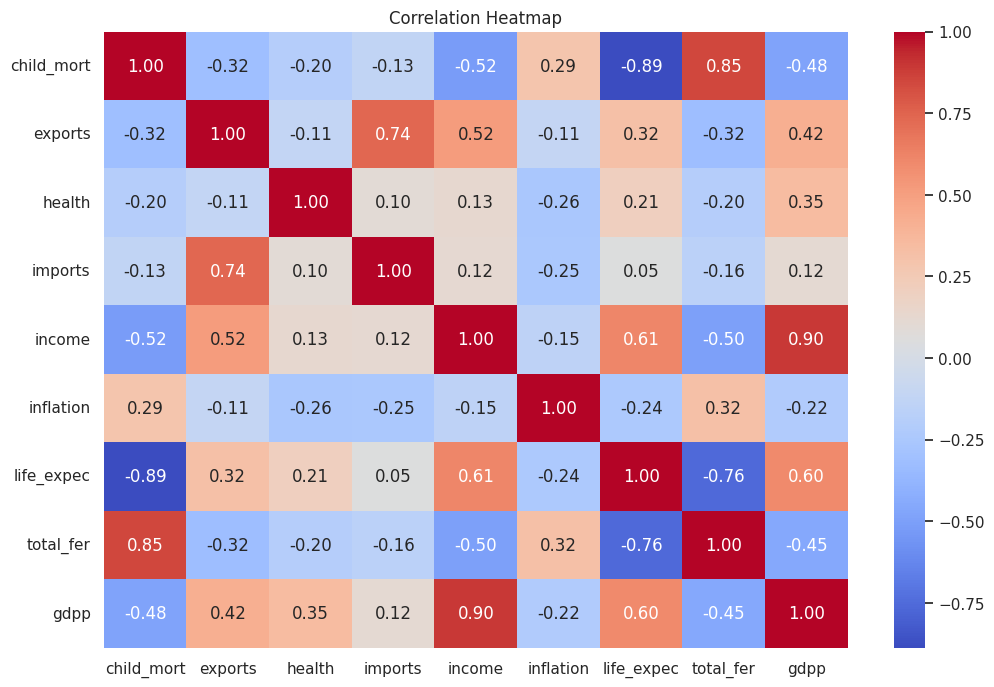

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

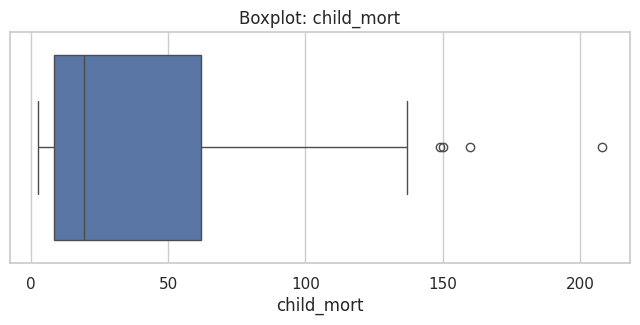

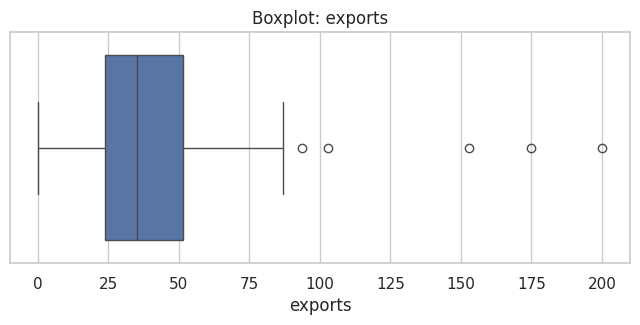

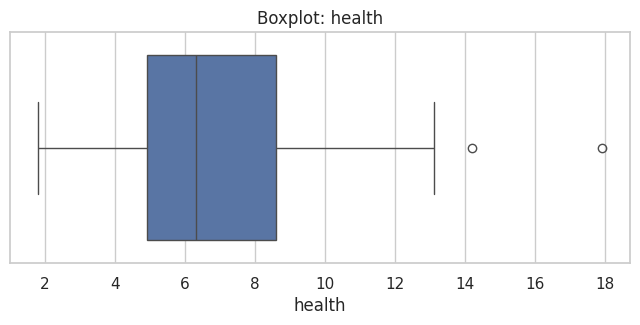

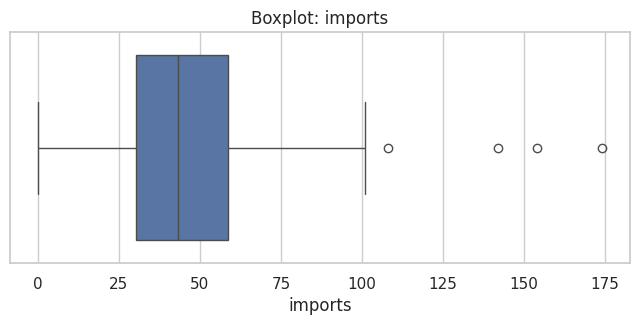

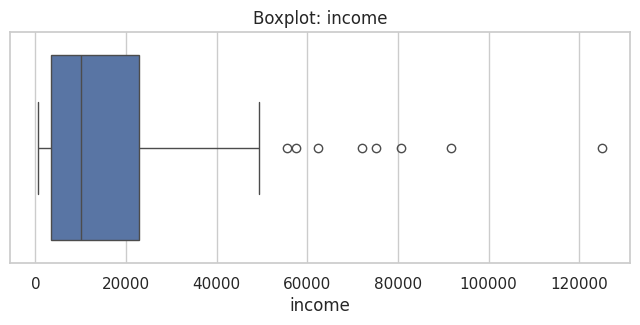

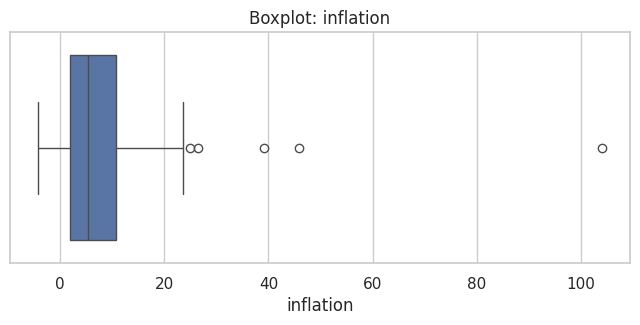

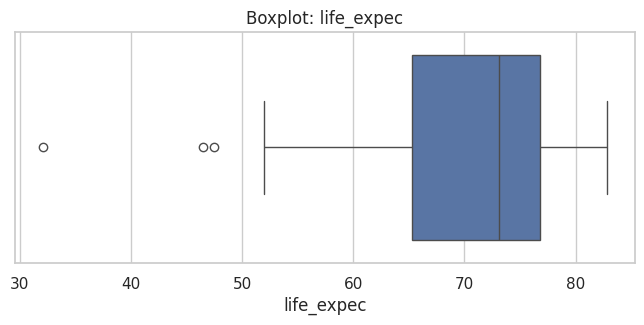

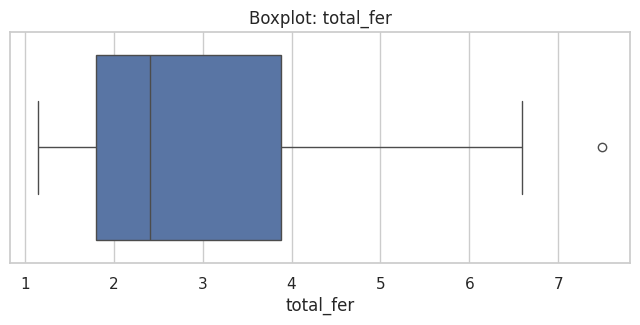

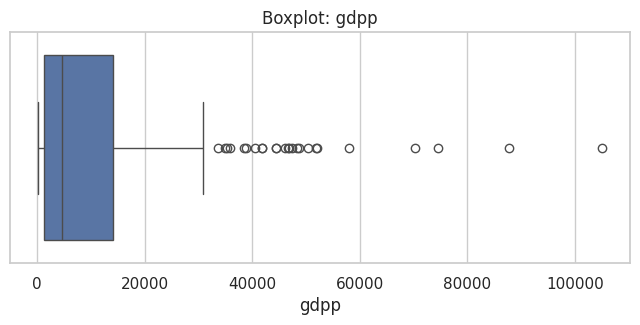

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [ ]:
features = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print("Features shape:", features.shape)
print("Scaled data shape:", X_scaled.shape)

features.head()


Features shape: (167, 9)
Scaled data shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 9) K-Means: Elbow method

    k      inertia
0   2  1050.214558
1   3   831.424435
2   4   700.520537
3   5   620.163371
4   6   558.469660
5   7   495.807946
6   8   457.586148
7   9   427.803672
8  10   403.229613


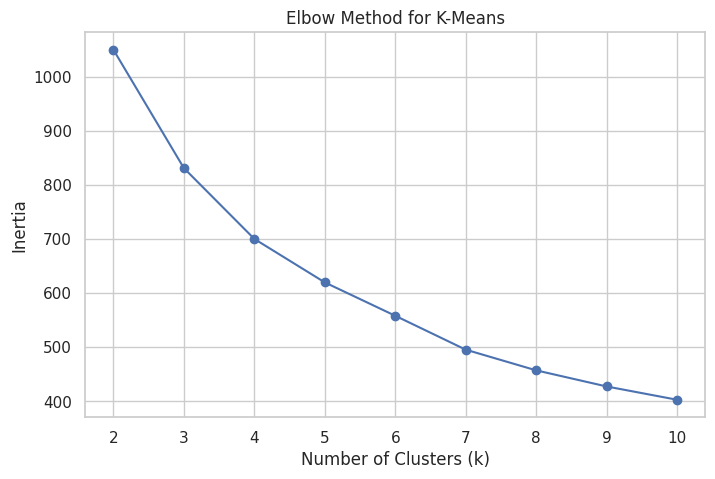

In [ ]:
k_values = range(2, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

elbow_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias
})

print(elbow_results)

plt.figure(figsize=(8, 5))
plt.plot(elbow_results["k"], elbow_results["inertia"], marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()



## 10) Train K-Means

In [ ]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, df["kmeans_cluster"])

print("Silhouette Score for K-Means with k =", best_k, ":", silhouette, 4)

if "country" in df.columns:
    df[["country", "kmeans_cluster"]].head(10)
else:
    df[["kmeans_cluster"]].head(10)

Silhouette Score for K-Means with k = 3 : 0.28329575683463126 4


## 11) Try DBSCAN

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)
print("DBSCAN cluster counts:")
print(df["dbscan_cluster"].value_counts().sort_index())
df[["country", "kmeans_cluster", "dbscan_cluster"]].head(10)

DBSCAN cluster counts:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


,country,kmeans_cluster,dbscan_cluster
0,Afghanistan,1,0
1,Albania,2,0
2,Algeria,2,0
3,Angola,1,-1
4,Antigua and Barbuda,2,0
5,Argentina,2,0
6,Armenia,2,0
7,Australia,0,0
8,Austria,0,0
9,Azerbaijan,2,0


## 12) PCA visualization

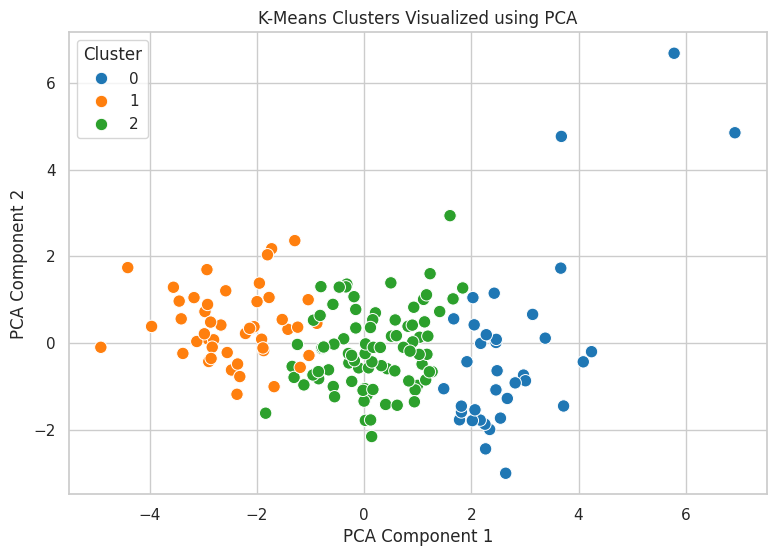

Explained variance ratio: [0.4595174  0.17181626]


In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "kmeans_cluster": df["kmeans_cluster"]
})
pca_df["country"] = df["country"]
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="kmeans_cluster",
    palette="tab10",
    s=80
)

plt.title("K-Means Clusters Visualized using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()
print("Explained variance ratio:", pca.explained_variance_ratio_)

## 13) Cluster profiling

In [ ]:
profile = df.groupby("kmeans_cluster")[numeric_cols].mean().round(2)
display(profile)
for cluster_id in sorted(df["kmeans_cluster"].unique()):
    sample_countries = df[df["kmeans_cluster"] == cluster_id]["country"].head(10).tolist()
    print("Cluster", cluster_id, "sample countries:", sample_countries)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


Cluster 0 sample countries: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']
Cluster 1 sample countries: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros']
Cluster 2 sample countries: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']


## Section 14: Insights

1. The countries are divided into three clear groups based on their health and economic conditions.

2. One group has countries with high child mortality, low income, low GDP per person, and lower life expectancy. These countries need more focus on healthcare, basic facilities, and economic support.

3. Another group has countries with high income, high GDP per person, low child mortality, and better life expectancy. These countries are more developed and economically stronger.

4. The third group contains countries that are in the middle stage. They are not very poor, but they are also not as developed as the top economic countries.

5. The PCA plot helps us see these groups visually. Countries with similar conditions are placed closer together, and countries with different conditions are placed farther apart.
